## Data description

link: https://docs.google.com/document/d/1X2GbykWLQlnttuWn8yi8y_jkvNyixsIJT8VYAbNi_2c/edit?usp=sharing


###  CSV Data Summary (saved fields, units, physical meaning)

| CSV File | Column | Unit | Physical Meaning |
|---|---|---|---|
| `PointCloud_snr.csv` | `timestamp_s` | s | Time from start of capture/frame timeline |
| `PointCloud_snr.csv` | `frame_number` | index | Radar frame ID |
| `PointCloud_snr.csv` | `point_index` | index | Detection ID inside a frame |
| `PointCloud_snr.csv` | `x` | m | Lateral coordinate in sensor Cartesian frame |
| `PointCloud_snr.csv` | `y` | m | Forward/depth coordinate from sensor |
| `PointCloud_snr.csv` | `z` | m | Vertical coordinate (height) |
| `PointCloud_snr.csv` | `doppler` | m/s | Radial velocity of detection (sign indicates direction) |
| `PointCloud_snr.csv` | `range` | m | Radial distance from sensor |
| `PointCloud_snr.csv` | `aoa` | degree | Estimated angle of arrival |
| `PointCloud_snr.csv` | `snr` | dB | Signal-to-noise ratio of detection |
| `PointCloud_snr.csv` | `noise` | dB (sensor scale) | Background noise estimate near detection |
| `range_doppler.csv` | `timestamp_s` | s | Time of frame |
| `range_doppler.csv` | `frame_number` | index | Radar frame ID |
| `range_doppler.csv` | `range_bin` | bin index | Discrete distance-bin location in FFT grid |
| `range_doppler.csv` | `doppler_bin` | bin index | Discrete velocity-bin location in FFT grid |
| `range_doppler.csv` | `signal_strength` | power/counts (arb.) | Return energy/intensity at (`range_bin`, `doppler_bin`) |


In [8]:
from pathlib import Path
import pandas as pd


def first_existing_dir(parent: Path, names):
    for name in names:
        p = parent / name
        if p.exists() and p.is_dir():
            return p
    return None


def first_existing_file(parent: Path, names):
    for name in names:
        p = parent / name
        if p.exists() and p.is_file():
            return p
    return None


def find_root(start: Path) -> Path:
    markers = ["Single Activity", "Single Activity Data", "Multipersonal Activity", "Multi personal activity"]
    for base in [start, *start.parents]:
        if any((base / m).exists() for m in markers):
            return base
    return start


def session_summary_table(dataset_root: Path, dataset_label: str) -> pd.DataFrame:
    data_root = first_existing_dir(dataset_root, ["3D data", "3D", "3d data", "3d"])
    if data_root is None:
        return pd.DataFrame(columns=["activity", "sample", "range_doppler_shape", "pointcloud_shape", "n_frames"])

    rows = []
    for activity_dir in sorted([d for d in data_root.iterdir() if d.is_dir()]):
        for sample_dir in sorted([d for d in activity_dir.iterdir() if d.is_dir()]):
            rd_path = sample_dir / "range_doppler.csv"
            pc_path = first_existing_file(sample_dir, ["PointCloud_snr.csv", "point_cloud_snr.csv", "points_cloud_snr.csv"])

            rd_shape = "missing"
            pc_shape = "missing"
            n_frames = 0

            if rd_path.exists():
                rd_df = pd.read_csv(rd_path)
                rd_shape = f"{rd_df.shape[0]} x {rd_df.shape[1]}"
                if "frame_number" in rd_df.columns:
                    n_frames = int(pd.to_numeric(rd_df["frame_number"], errors="coerce").dropna().astype(int).nunique())
                else:
                    n_frames = int(len(rd_df))

            if pc_path is not None:
                pc_df = pd.read_csv(pc_path)
                pc_shape = f"{pc_df.shape[0]} x {pc_df.shape[1]}"

            rows.append({
                "activity": activity_dir.name,
                "sample": sample_dir.name,
                "range_doppler_shape": rd_shape,
                "pointcloud_shape": pc_shape,
                "n_frames": n_frames,
            })

    out = pd.DataFrame(rows).sort_values(["activity", "sample"]).reset_index(drop=True)
    print(f"{dataset_label}: {len(out)} sessions")
    return out


research_root = find_root(Path.cwd())
single_root = first_existing_dir(research_root, ["Single Activity", "Single Activity Data"])
multi_root = first_existing_dir(research_root, ["Multipersonal Activity", "Multi personal activity", "Multi-personal Activity"])

if single_root is None:
    raise FileNotFoundError("Single Activity folder not found")
if multi_root is None:
    raise FileNotFoundError("Multipersonal Activity folder not found")

single_summary_table = session_summary_table(single_root, "Single Activity")
multi_summary_table = session_summary_table(multi_root, "Multipersonal Activity")

print("\nSingle Activity Summary")
display(single_summary_table)

print("Multipersonal Activity Summary")
display(multi_summary_table)

Single Activity: 20 sessions
Multipersonal Activity: 25 sessions

Single Activity Summary


,activity,sample,range_doppler_shape,pointcloud_shape,n_frames
0,Sitting,1 m,1196032 x 5,401 x 11,146
1,Sitting,2 m,1089536 x 5,292 x 11,133
2,Sitting,3 m,1024000 x 5,151 x 11,125
3,Sitting,4 m,1122304 x 5,152 x 11,137
4,Sitting,5 m,1146880 x 5,159 x 11,140
5,Standing,1 m,1155072 x 5,301 x 11,141
6,Standing,2 m,1163264 x 5,316 x 11,142
7,Standing,3 m,1146880 x 5,201 x 11,140
8,Standing,4 m,1097728 x 5,181 x 11,134
9,Standing,5 m,1318912 x 5,193 x 11,161


Multipersonal Activity Summary


,activity,sample,range_doppler_shape,pointcloud_shape,n_frames
0,Approaching,1 m,827392 x 5,663 x 11,101
1,Approaching,2 m,892928 x 5,632 x 11,109
2,Approaching,2.5 m,745472 x 5,631 x 11,91
3,Approaching,3 m,720896 x 5,614 x 11,88
4,Approaching,4 m,860160 x 5,700 x 11,105
5,Sitting,1 m,1187840 x 5,650 x 11,145
6,Sitting,2 m,1286144 x 5,785 x 11,157
7,Sitting,2.5 m,1359872 x 5,881 x 11,166
8,Sitting,3 m,1449984 x 5,1047 x 11,177
9,Sitting,4 m,1220608 x 5,879 x 11,149


### Plotting Angle of Arrival AoA


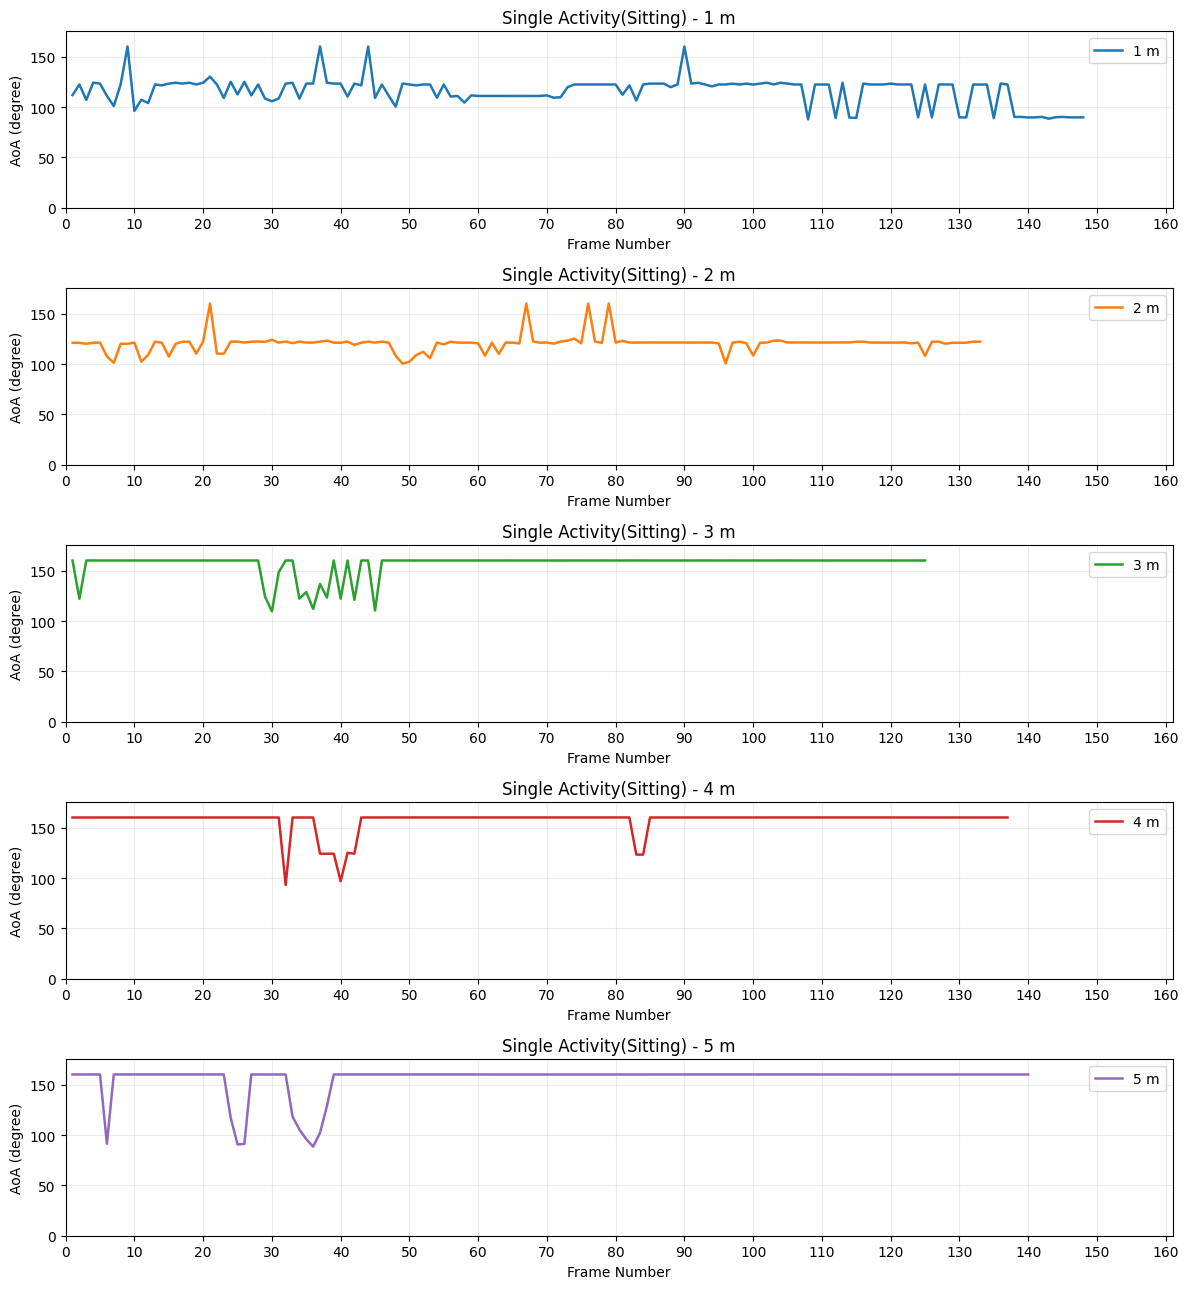

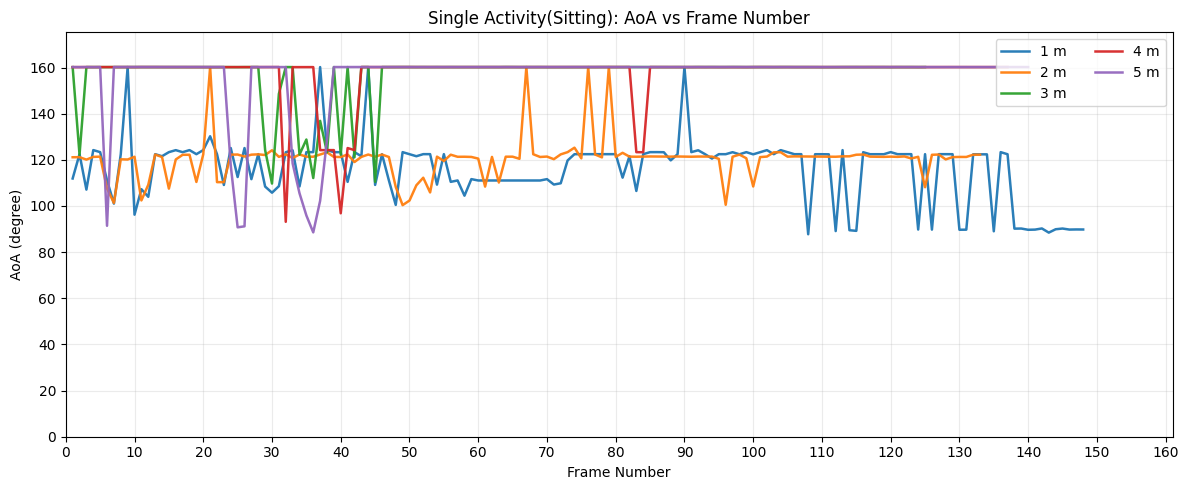

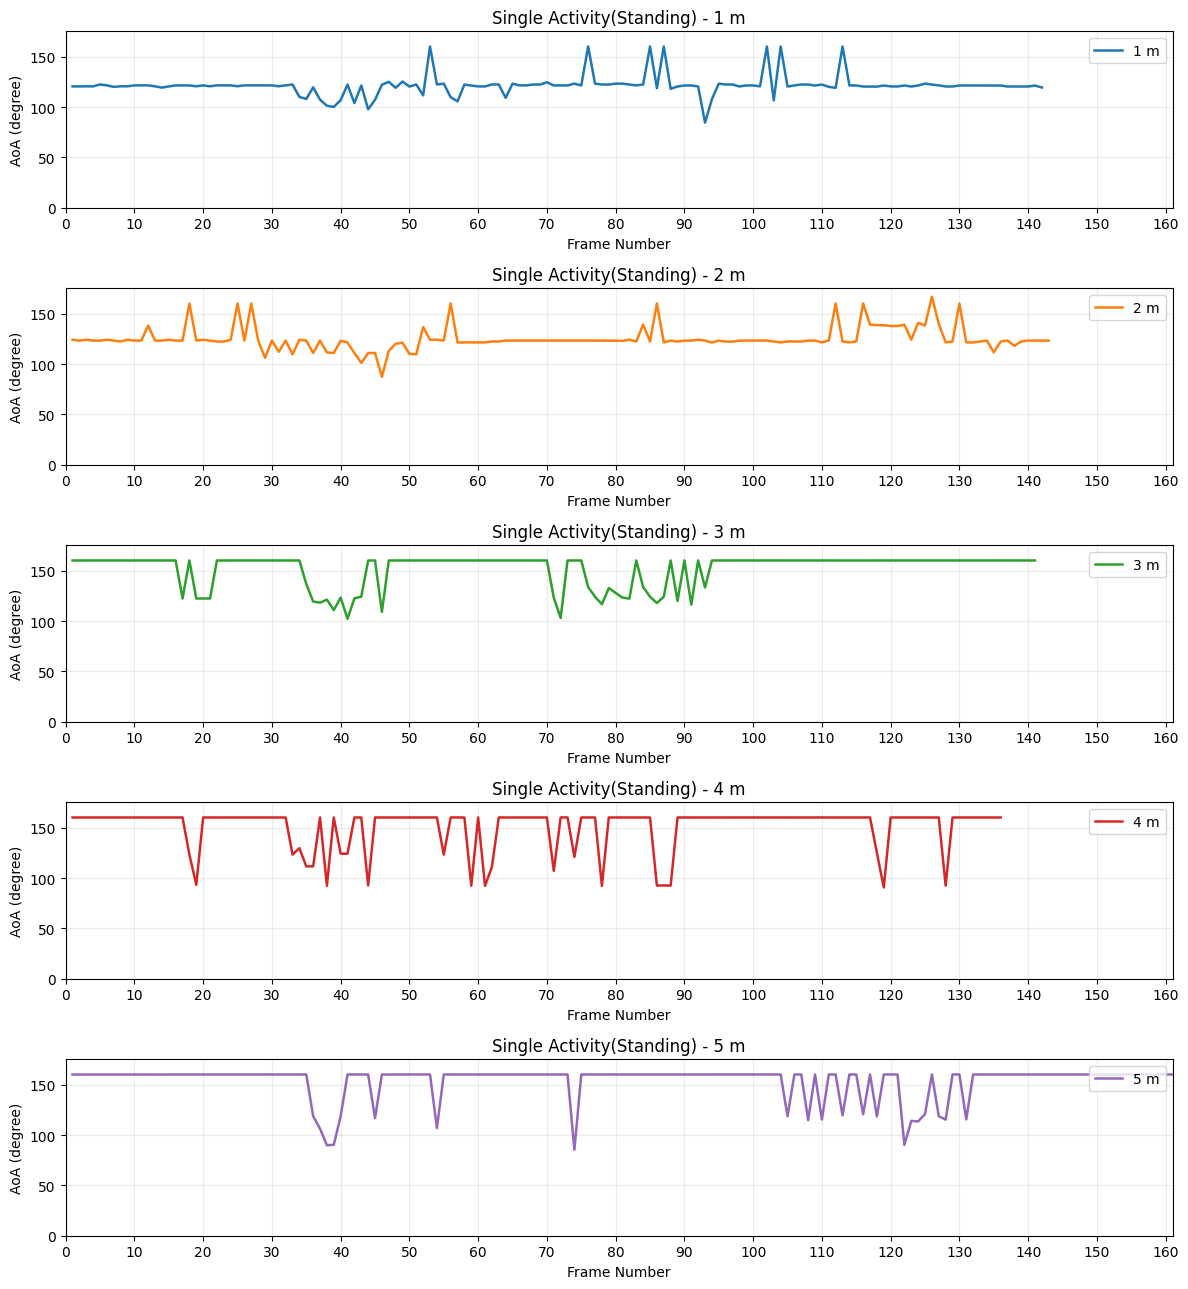

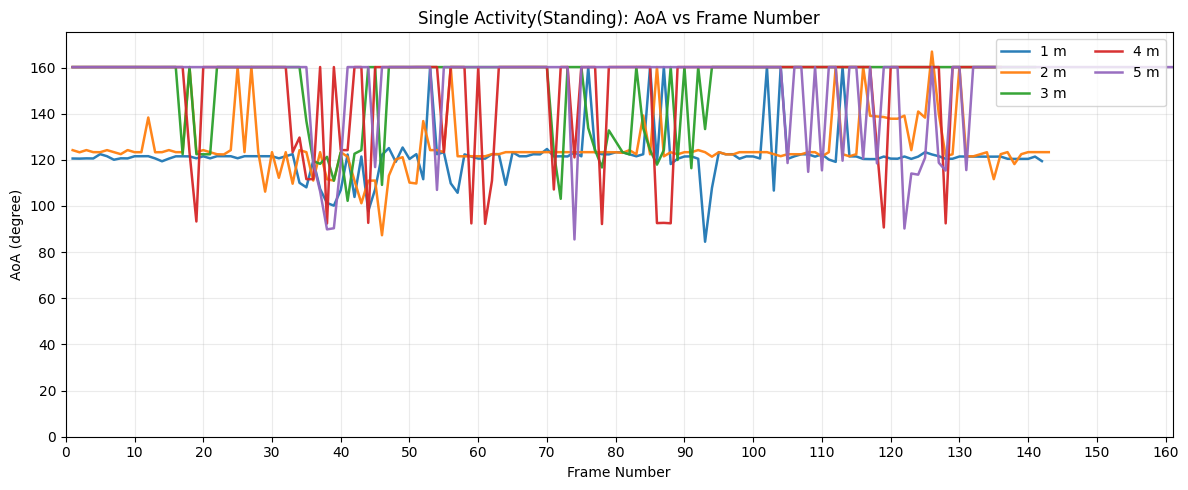

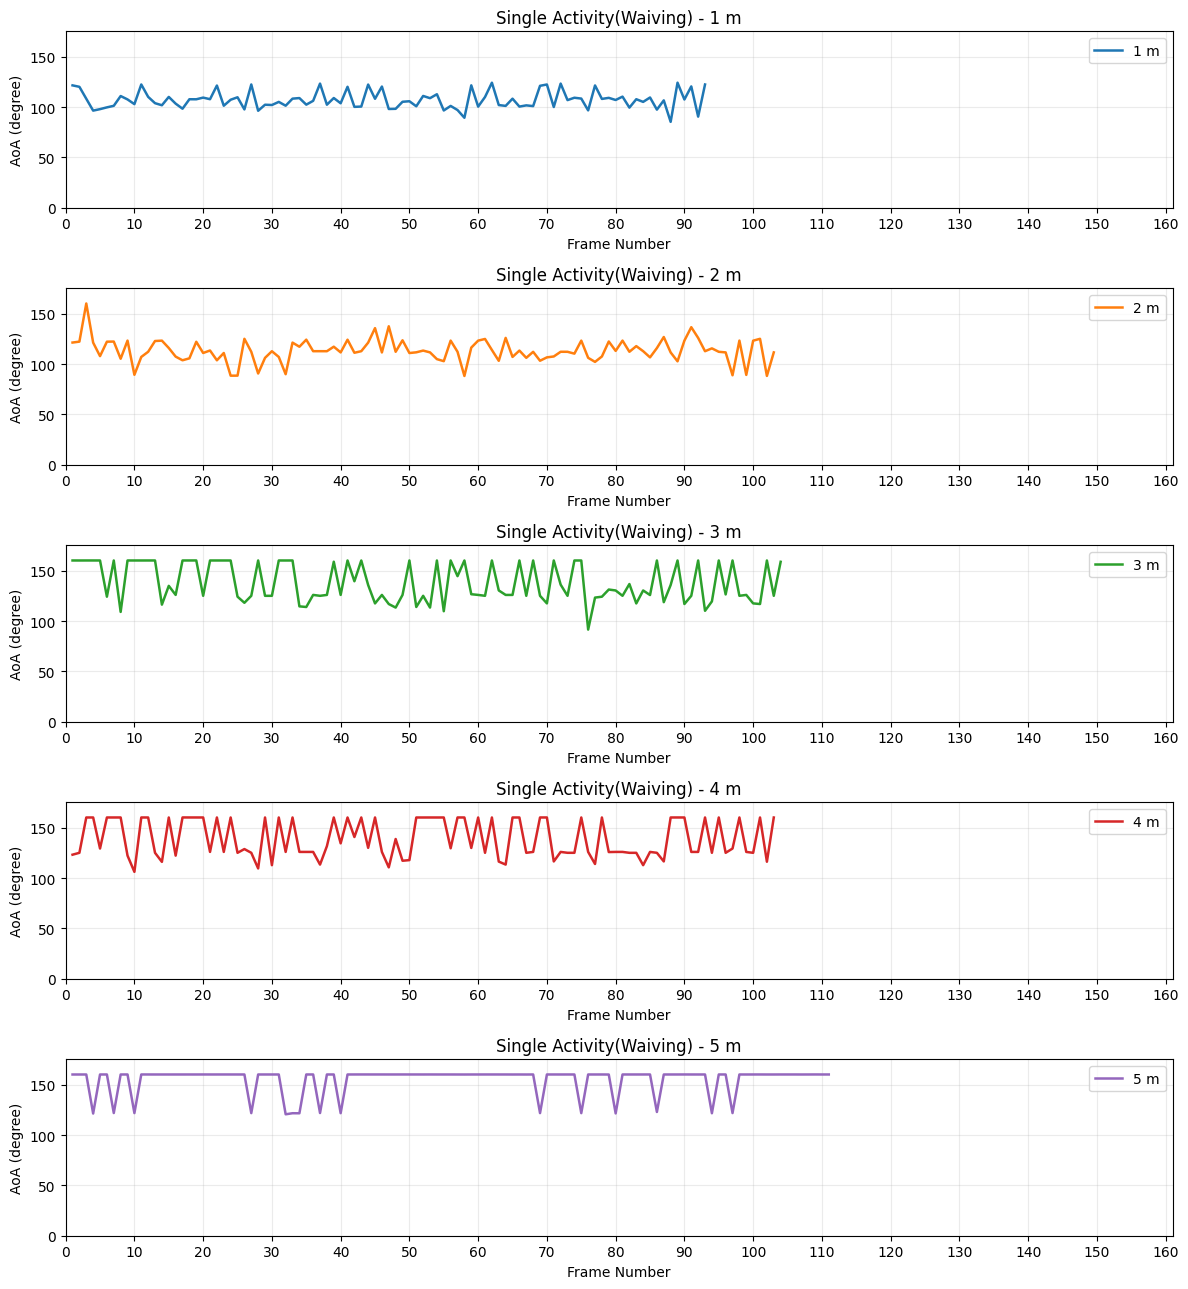

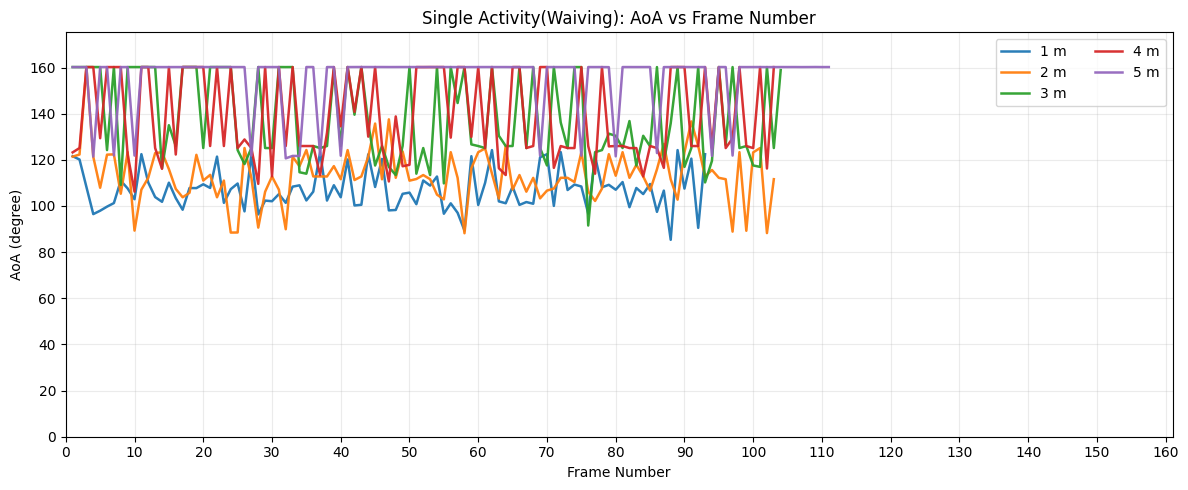

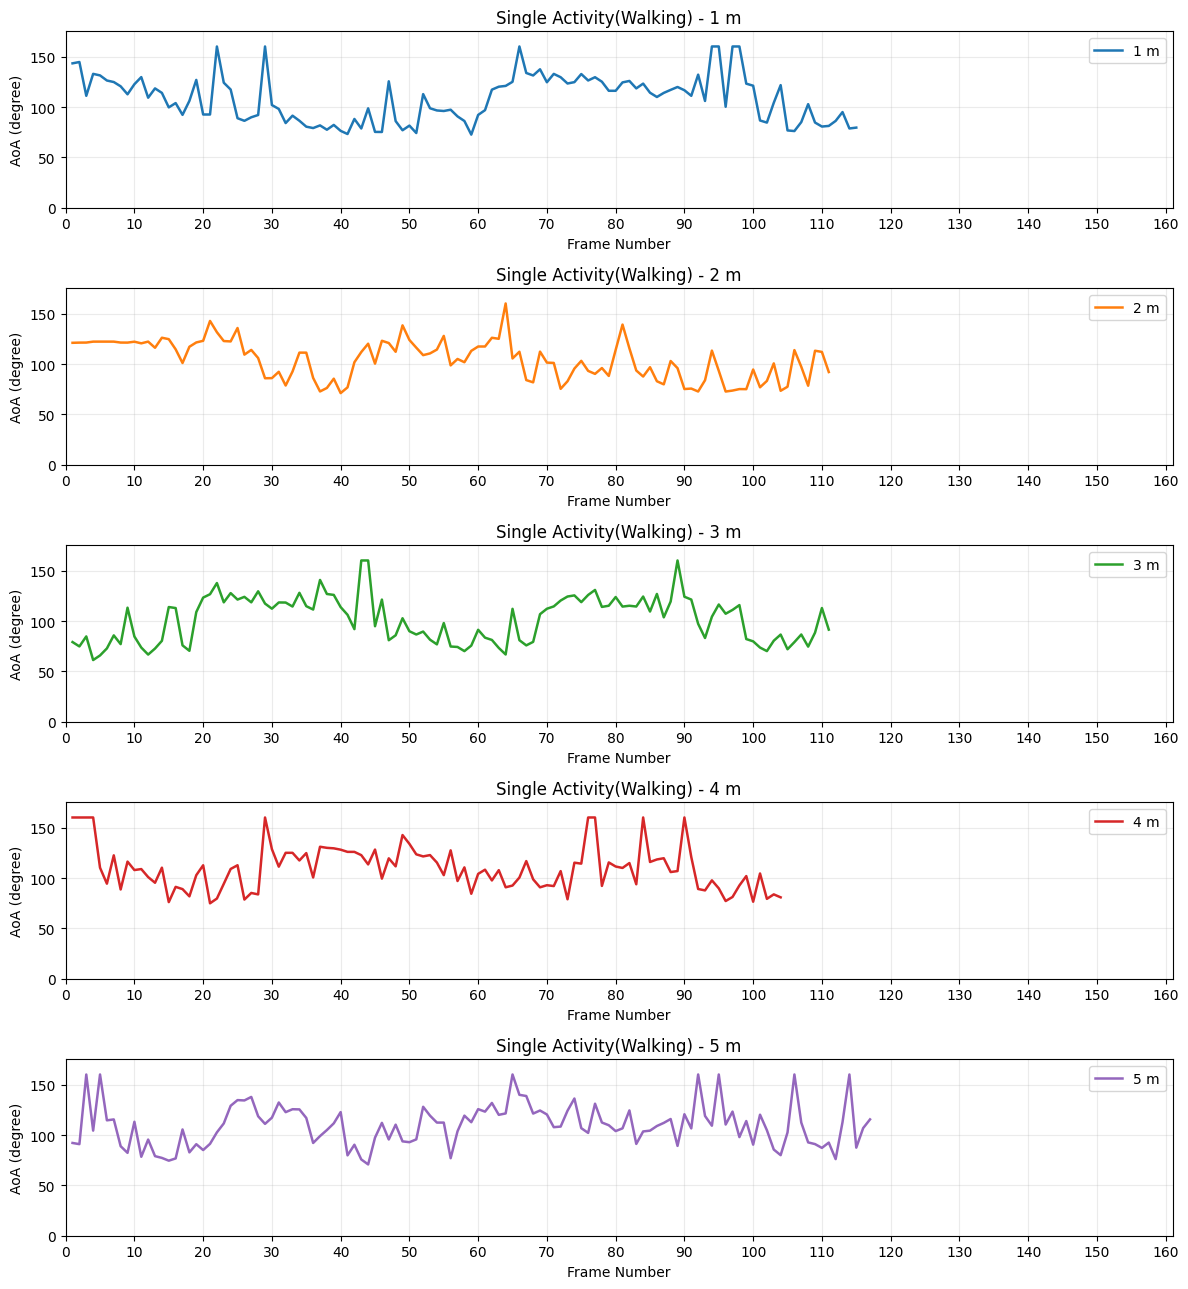

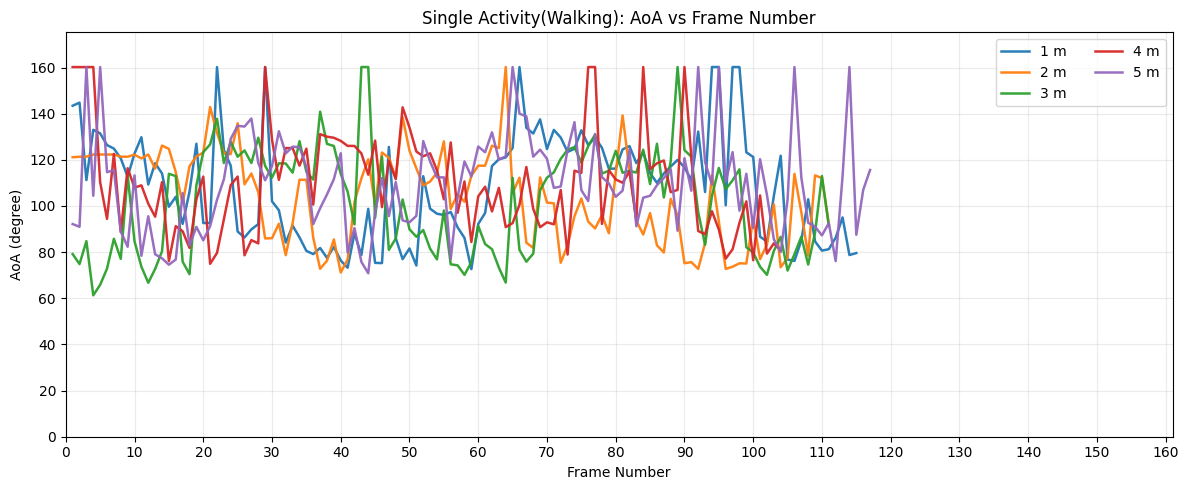

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# Reuse objects from Cell 3.
if "single_root" not in globals() or single_root is None:
    raise RuntimeError("Run Cell 3 first.")
if "first_existing_dir" not in globals() or "first_existing_file" not in globals():
    raise RuntimeError("Run Cell 3 first.")

single_3d_root = first_existing_dir(single_root, ["3D data"])
if single_3d_root is None:
    raise FileNotFoundError("Single Activity 3D folder not found.")


def aoa_per_frame(csv_path):
    df = pd.read_csv(csv_path)
    cols = {str(c).strip().lower(): c for c in df.columns}
    if "frame_number" not in cols or "aoa" not in cols:
        return pd.DataFrame(columns=["frame_number", "aoa"])

    out = df[[cols["frame_number"], cols["aoa"]]].copy()
    out.columns = ["frame_number", "aoa"]
    out["frame_number"] = pd.to_numeric(out["frame_number"], errors="coerce")
    out["aoa"] = pd.to_numeric(out["aoa"], errors="coerce")
    out = out.dropna(subset=["frame_number", "aoa"])
    if out.empty:
        return out

    out["frame_number"] = out["frame_number"].astype(int)
    return out.groupby("frame_number", as_index=False)["aoa"].mean().sort_values("frame_number")


def session_sort_key(name):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


# Build curves first so all plots can use the same axis origin/range.
activity_curves = {}
all_frame_max = 0
all_aoa_max = 0.0

for activity_dir in sorted([d for d in single_3d_root.iterdir() if d.is_dir()]):
    session_dirs = sorted(
        [d for d in activity_dir.iterdir() if d.is_dir()],
        key=lambda p: session_sort_key(p.name),
    )

    session_curves = []
    for i, session_dir in enumerate(session_dirs):
        csv_path = first_existing_file(session_dir, ["PointCloud_snr.csv"])
        if csv_path is None:
            continue

        curve = aoa_per_frame(csv_path)
        if curve.empty:
            continue

        color = plt.get_cmap("tab10")(i % 10)
        session_curves.append((session_dir.name, curve, color))

        all_frame_max = max(all_frame_max, int(curve["frame_number"].max()))
        all_aoa_max = max(all_aoa_max, float(curve["aoa"].max()))

    if session_curves:
        activity_curves[activity_dir.name] = session_curves

if not activity_curves:
    raise ValueError("No valid AoA data found to plot.")

# Same origin and range for all plots.
x_min, x_max = 0, all_frame_max
y_min, y_max = 0.0, all_aoa_max * 1.05

for activity_name, session_curves in activity_curves.items():
    # 1) Distance-wise plots for this activity in one figure.
    n = len(session_curves)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (session_name, curve, color) in zip(axes, session_curves):
        ax.plot(curve["frame_number"], curve["aoa"], color=color, linewidth=1.8)
        ax.set_title(f"Single Activity({activity_name}) - {session_name}")
        ax.set_ylabel("AoA (degree)")
        ax.set_xlabel("Frame Number")
        ax.grid(alpha=0.25)
        ax.legend([session_name], loc="upper right")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.tick_params(axis="x", labelbottom=True)

    plt.tight_layout()
    plt.show()

    # 2) Combined graph for this activity (all distances together).
    plt.figure(figsize=(12, 5))
    for session_name, curve, color in session_curves:
        plt.plot(
            curve["frame_number"],
            curve["aoa"],
            label=session_name,
            color=color,
            linewidth=1.8,
            alpha=0.95,
        )

    plt.title(f"Single Activity({activity_name}): AoA vs Frame Number")
    plt.xlabel("Frame Number")
    plt.ylabel("AoA (degree)")
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, loc="upper right")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().xaxis.set_major_locator(MultipleLocator(10))
    plt.tight_layout()
    plt.show()

## Fusion Modeling

- Point-cloud branch: CNN + LSTM (spatial + temporal features)
- Range-Doppler branch: 3D CNN (spatial-temporal RD features)
- Feature fusion: concatenate both branch features and classify

## Range-Doppler Modeling (Single Activity First)

This section builds a range-doppler-only activity classifier in a clear sequence:
1. load and inspect raw input sessions
2. explain preprocessing
3. build train/validation sets
4. train 3D CNN model
5. report metrics and confusion matrix

In [25]:
# Cell 1: Setup and configuration
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TARGET_DATASET = "Single Activity"  # options: "Single Activity", "Multipersonal Activity"
RD_GRID = (32, 32)                   # (range_bins, doppler_bins)
DESIRED_SEQ_LEN = 10                 # auto-adjusted if needed
STRIDE = 1                           # more overlap -> more train windows
TRAIN_SESSIONS_PER_ACTIVITY = 3
VAL_SESSIONS_PER_ACTIVITY = 2
VAL_RATIO = 0.2
EPOCHS = 80
BATCH_SIZE = 20

if "first_existing_dir" not in globals():
    def first_existing_dir(parent: Path, names):
        for name in names:
            p = parent / name
            if p.exists() and p.is_dir():
                return p
        return None

if "find_root" not in globals():
    def find_root(start: Path) -> Path:
        markers = ["Single Activity", "Single Activity Data", "Multipersonal Activity", "Multi personal activity"]
        for base in [start, *start.parents]:
            if any((base / m).exists() for m in markers):
                return base
        return start

research_root = find_root(Path.cwd())
single_root_local = first_existing_dir(research_root, ["Single Activity", "Single Activity Data"])
multi_root_local = first_existing_dir(research_root, ["Multipersonal Activity", "Multi personal activity", "Multi-personal Activity"])

if TARGET_DATASET == "Single Activity":
    dataset_root = single_root_local
else:
    dataset_root = multi_root_local

if dataset_root is None:
    raise FileNotFoundError(f"Dataset folder not found for: {TARGET_DATASET}")

three_d_root = first_existing_dir(dataset_root, ["3D data", "3D", "3d data", "3d"])
if three_d_root is None:
    raise FileNotFoundError(f"3D data folder not found under: {dataset_root}")

print("Dataset selected:", TARGET_DATASET)
print("Grid:", RD_GRID, "| Desired sequence length:", DESIRED_SEQ_LEN, "| Stride:", STRIDE)
print("Sessions split target (per activity): train=", TRAIN_SESSIONS_PER_ACTIVITY, ", val=", VAL_SESSIONS_PER_ACTIVITY, sep="")
print("Epochs:", EPOCHS, "| Batch size:", BATCH_SIZE)

Dataset selected: Single Activity
Grid: (32, 32) | Desired sequence length: 10 | Stride: 1
Sessions split target (per activity): train=3, val=2
Epochs: 80 | Batch size: 20


In [26]:
# Cell 2: Read and print initial range-doppler sessions

def read_rd_csv(rd_path: Path) -> pd.DataFrame:
    df = pd.read_csv(rd_path)
    cols = {str(c).strip().lower(): c for c in df.columns}
    needed = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]
    missing = [c for c in needed if c not in cols]
    if missing:
        raise ValueError(f"Missing columns in {rd_path.name}: {missing}")

    out = df[[cols["frame_number"], cols["range_bin"], cols["doppler_bin"], cols["signal_strength"]]].copy()
    out.columns = needed
    for c in needed:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.dropna(subset=needed)
    out["frame_number"] = out["frame_number"].astype(int)
    return out


def sample_sort_key(name: str):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


session_rows = []
for activity_dir in sorted([d for d in three_d_root.iterdir() if d.is_dir()]):
    sample_dirs = sorted([d for d in activity_dir.iterdir() if d.is_dir()], key=lambda p: sample_sort_key(p.name))
    for sample_dir in sample_dirs:
        rd_path = sample_dir / "range_doppler.csv"
        if not rd_path.exists():
            continue

        rd_df = read_rd_csv(rd_path)
        frame_ids = np.sort(rd_df["frame_number"].unique())

        session_rows.append({
            "activity": activity_dir.name,
            "sample": sample_dir.name,
            "rd_path": str(rd_path),
            "n_rows": int(len(rd_df)),
            "n_frames": int(len(frame_ids)),
            "range_bin_min": int(rd_df["range_bin"].min()),
            "range_bin_max": int(rd_df["range_bin"].max()),
            "doppler_bin_min": int(rd_df["doppler_bin"].min()),
            "doppler_bin_max": int(rd_df["doppler_bin"].max()),
        })

session_df_rd = pd.DataFrame(session_rows).sort_values(["activity", "sample"]).reset_index(drop=True)
if session_df_rd.empty:
    raise ValueError("No valid range_doppler.csv sessions found.")

print("Initial input data selected for modeling")
print("Total sessions:", len(session_df_rd))
print("Activities:", sorted(session_df_rd["activity"].unique()))
print("Frame count range:", int(session_df_rd["n_frames"].min()), "to", int(session_df_rd["n_frames"].max()))

display(session_df_rd[[
    "activity", "sample", "n_rows", "n_frames",
    "range_bin_min", "range_bin_max", "doppler_bin_min", "doppler_bin_max"
]])

Initial input data selected for modeling
Total sessions: 20
Activities: ['Sitting', 'Standing', 'Waiving', 'Walking']
Frame count range: 93 to 161


,activity,sample,n_rows,n_frames,range_bin_min,range_bin_max,doppler_bin_min,doppler_bin_max
0,Sitting,1 m,1196032,146,0,127,0,63
1,Sitting,2 m,1089536,133,0,127,0,63
2,Sitting,3 m,1024000,125,0,127,0,63
3,Sitting,4 m,1122304,137,0,127,0,63
4,Sitting,5 m,1146880,140,0,127,0,63
5,Standing,1 m,1155072,141,0,127,0,63
6,Standing,2 m,1163264,142,0,127,0,63
7,Standing,3 m,1146880,140,0,127,0,63
8,Standing,4 m,1097728,134,0,127,0,63
9,Standing,5 m,1318912,161,0,127,0,63


In [27]:
# Cell 3: Choose sequence length and define train/validation sessions
min_frames = int(session_df_rd["n_frames"].min())
if min_frames < 4:
    raise ValueError(f"Some sessions have too few frames ({min_frames}). Need at least 4 frames.")

SEQ_LEN = min(DESIRED_SEQ_LEN, min_frames)
STRIDE_USED = min(max(1, STRIDE), max(1, SEQ_LEN - 1))

train_session_rows = []
val_session_rows = []

for activity, g in session_df_rd.groupby("activity", sort=True):
    g = g.sort_values("sample", key=lambda s: s.map(sample_sort_key)).reset_index(drop=True)
    n = len(g)

    # Target split requested: 3 train sessions + 2 validation sessions per activity.
    if n >= (TRAIN_SESSIONS_PER_ACTIVITY + VAL_SESSIONS_PER_ACTIVITY):
        train_part = g.iloc[:TRAIN_SESSIONS_PER_ACTIVITY].copy()
        val_part = g.iloc[TRAIN_SESSIONS_PER_ACTIVITY:TRAIN_SESSIONS_PER_ACTIVITY + VAL_SESSIONS_PER_ACTIVITY].copy()
    else:
        # Fallback for smaller activities.
        n_train = min(TRAIN_SESSIONS_PER_ACTIVITY, max(1, n - 1))
        n_val = n - n_train
        if n_val == 0 and n > 1:
            n_val = 1
            n_train = n - 1
        train_part = g.iloc[:n_train].copy()
        val_part = g.iloc[n_train:n_train + n_val].copy()

    train_session_rows.append(train_part)
    val_session_rows.append(val_part)

train_sessions_df = pd.concat(train_session_rows, ignore_index=True)
val_sessions_df = pd.concat(val_session_rows, ignore_index=True)

print("Chosen sequence settings")
print("DESIRED_SEQ_LEN:", DESIRED_SEQ_LEN, "-> SEQ_LEN used:", SEQ_LEN)
print("STRIDE:", STRIDE, "-> STRIDE used:", STRIDE_USED)
print("\nTrain sessions:", len(train_sessions_df), "| Validation sessions:", len(val_sessions_df))

print("\nTrain sessions by activity")
display(train_sessions_df[["activity", "sample", "n_frames"]])

print("Validation sessions by activity")
display(val_sessions_df[["activity", "sample", "n_frames"]])

Chosen sequence settings
DESIRED_SEQ_LEN: 10 -> SEQ_LEN used: 10
STRIDE: 1 -> STRIDE used: 1

Train sessions: 12 | Validation sessions: 8

Train sessions by activity


,activity,sample,n_frames
0,Sitting,1 m,146
1,Sitting,2 m,133
2,Sitting,3 m,125
3,Standing,1 m,141
4,Standing,2 m,142
5,Standing,3 m,140
6,Waiving,1 m,93
7,Waiving,2 m,103
8,Waiving,3 m,104
9,Walking,1 m,115


Validation sessions by activity


,activity,sample,n_frames
0,Sitting,4 m,137
1,Sitting,5 m,140
2,Standing,4 m,134
3,Standing,5 m,161
4,Waiving,4 m,103
5,Waiving,5 m,109
6,Walking,4 m,103
7,Walking,5 m,115


In [28]:
# Cell 4: Preprocess range-doppler and create windows

def frame_to_rd_map(frame_df: pd.DataFrame, grid=(32, 32)) -> np.ndarray:
    h, w = grid
    mat = np.zeros((h, w), dtype=np.float32)

    rb = frame_df["range_bin"].to_numpy(dtype=np.int64)
    db = frame_df["doppler_bin"].to_numpy(dtype=np.int64)
    sig = frame_df["signal_strength"].to_numpy(dtype=np.float32)

    valid = (rb >= 0) & (rb < h) & (db >= 0) & (db < w)
    rb = rb[valid]
    db = db[valid]
    sig = sig[valid]

    if len(sig) > 0:
        np.add.at(mat, (rb, db), sig)
    return mat


def make_windows(arr: np.ndarray, seq_len: int, stride: int):
    out = []
    for i in range(0, len(arr) - seq_len + 1, stride):
        out.append(arr[i:i + seq_len])
    return out


preprocess_steps = [
    "1) Keep required columns: frame_number, range_bin, doppler_bin, signal_strength",
    f"2) Convert each frame to fixed grid {RD_GRID} by accumulating signal_strength at [range_bin, doppler_bin]",
    "3) Percentile normalization per session: clip to p1-p99, then scale to [0, 1]",
    f"4) Build temporal windows with SEQ_LEN={SEQ_LEN} and STRIDE={STRIDE_USED}",
    "5) Add channel axis for 3D CNN input",
]

print("Preprocessing pipeline used")
for step in preprocess_steps:
    print("-", step)


X_train_list, y_train_list, train_origin = [], [], []
X_val_list, y_val_list, val_origin = [], [], []


def process_session_block(session_block_df: pd.DataFrame, x_list: list, y_list: list, origin_list: list):
    for _, row in session_block_df.iterrows():
        rd_df = read_rd_csv(Path(row["rd_path"]))
        frame_ids = np.sort(rd_df["frame_number"].unique())

        frame_maps = []
        used_frames = []
        for f in frame_ids:
            part = rd_df[rd_df["frame_number"] == f]
            frame_maps.append(frame_to_rd_map(part, grid=RD_GRID))
            used_frames.append(int(f))

        frame_maps = np.asarray(frame_maps, dtype=np.float32)
        if len(frame_maps) < SEQ_LEN:
            continue

        lo, hi = np.percentile(frame_maps, [1, 99])
        frame_maps = np.clip((frame_maps - lo) / (hi - lo + 1e-6), 0.0, 1.0)

        windows = make_windows(frame_maps, SEQ_LEN, STRIDE_USED)
        for i, w in enumerate(windows):
            start_idx = i * STRIDE_USED
            end_idx = start_idx + SEQ_LEN - 1
            origin_list.append({
                "activity": row["activity"],
                "sample": row["sample"],
                "start_frame": used_frames[start_idx],
                "end_frame": used_frames[end_idx],
            })
            x_list.append(w)
            y_list.append(row["activity"])


process_session_block(train_sessions_df, X_train_list, y_train_list, train_origin)
process_session_block(val_sessions_df, X_val_list, y_val_list, val_origin)

if len(X_train_list) == 0 or len(X_val_list) == 0:
    raise ValueError("No train or validation windows generated. Increase data, reduce SEQ_LEN, or reduce STRIDE.")

X_train = np.asarray(X_train_list, dtype=np.float32)[..., np.newaxis]  # [N, T, H, W, 1]
X_val = np.asarray(X_val_list, dtype=np.float32)[..., np.newaxis]
y_train = np.asarray(y_train_list)
y_val = np.asarray(y_val_list)

label_encoder_rd = LabelEncoder()
y_train_enc = label_encoder_rd.fit_transform(y_train)
y_val_enc = label_encoder_rd.transform(y_val)
num_classes_rd = len(label_encoder_rd.classes_)

y_train_ohe = tf.keras.utils.to_categorical(y_train_enc, num_classes_rd)
y_val_ohe = tf.keras.utils.to_categorical(y_val_enc, num_classes_rd)

print("\nTraining data summary")
print("Classes:", list(label_encoder_rd.classes_))
print("X_train shape:", X_train.shape, "| X_val shape:", X_val.shape)
print("y_train shape:", y_train_ohe.shape, "| y_val shape:", y_val_ohe.shape)

print("\nWindows per class (train)")
print(pd.Series(y_train).value_counts().sort_index())

print("\nWindows per class (validation)")
print(pd.Series(y_val).value_counts().sort_index())

print("\nExamples of exact train windows used")
display(pd.DataFrame(train_origin).head(10))

print("Examples of exact validation windows used")
display(pd.DataFrame(val_origin).head(10))

Preprocessing pipeline used
- 1) Keep required columns: frame_number, range_bin, doppler_bin, signal_strength
- 2) Convert each frame to fixed grid (32, 32) by accumulating signal_strength at [range_bin, doppler_bin]
- 3) Percentile normalization per session: clip to p1-p99, then scale to [0, 1]
- 4) Build temporal windows with SEQ_LEN=10 and STRIDE=1
- 5) Add channel axis for 3D CNN input

Training data summary
Classes: ['Sitting', 'Standing', 'Waiving', 'Walking']
X_train shape: (1355, 10, 32, 32, 1) | X_val shape: (930, 10, 32, 32, 1)
y_train shape: (1355, 4) | y_val shape: (930, 4)

Windows per class (train)
Sitting     377
Standing    396
Waiving     273
Walking     309
Name: count, dtype: int64

Windows per class (validation)
Sitting     259
Standing    277
Waiving     194
Walking     200
Name: count, dtype: int64

Examples of exact train windows used


,activity,sample,start_frame,end_frame
0,Sitting,1 m,1,10
1,Sitting,1 m,2,12
2,Sitting,1 m,3,13
3,Sitting,1 m,4,14
4,Sitting,1 m,5,16
5,Sitting,1 m,6,17
6,Sitting,1 m,7,18
7,Sitting,1 m,8,19
8,Sitting,1 m,9,20
9,Sitting,1 m,10,21


Examples of exact validation windows used


,activity,sample,start_frame,end_frame
0,Sitting,4 m,1,10
1,Sitting,4 m,2,11
2,Sitting,4 m,3,12
3,Sitting,4 m,4,13
4,Sitting,4 m,5,14
5,Sitting,4 m,6,15
6,Sitting,4 m,7,16
7,Sitting,4 m,8,17
8,Sitting,4 m,9,18
9,Sitting,4 m,10,19


In [29]:
# Cell 5: Build the range-doppler 3D CNN model

def conv3d_block_rd(x, filters=32, block_name="b"):
    x = layers.Conv3D(filters, (3, 3, 3), strides=(1, 1, 1), padding="same", use_bias=False, name=f"{block_name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation("relu", name=f"{block_name}_relu1")(x)

    x = layers.Conv3D(filters, (3, 3, 3), strides=(1, 1, 1), padding="same", use_bias=False, name=f"{block_name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.Activation("relu", name=f"{block_name}_relu2")(x)

    x = layers.MaxPooling3D(pool_size=(2, 2, 2), strides=(1, 1, 1), padding="valid", name=f"{block_name}_pool")(x)
    x = layers.Dropout(0.20, name=f"{block_name}_drop")(x)
    return x


def build_range_doppler_3dcnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape, name="rd_input")
    x = conv3d_block_rd(inp, filters=32, block_name="blk1")
    x = conv3d_block_rd(x, filters=48, block_name="blk2")
    x = conv3d_block_rd(x, filters=64, block_name="blk3")
    x = layers.GlobalAveragePooling3D(name="gap")(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="dense_64")(x)
    x = layers.Dropout(0.40, name="dropout_head")(x)
    out = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    model = models.Model(inputs=inp, outputs=out, name="range_doppler_3dcnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


rd_model = build_range_doppler_3dcnn(X_train.shape[1:], num_classes_rd)
rd_model.summary()

Model: "range_doppler_3dcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rd_input (InputLayer)           │ (None, 10, 32, 32, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_conv1 (Conv3D)             │ (None, 10, 32, 32, 32) │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_bn1 (BatchNormalization)   │ (None, 10, 32, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_relu1 (Activation)         │ (None, 10, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_conv2 (Conv3D)             │ (None, 10, 32, 32, 32) │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_bn2 (BatchNormalization)   │ (None, 10, 32, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_relu2 (Activation)         │ (None, 10, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_pool (MaxPooling3D)        │ (None, 9, 31, 31, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk1_drop (Dropout)             │ (None, 9, 31, 31, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_conv1 (Conv3D)             │ (None, 9, 31, 31, 48)  │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_bn1 (BatchNormalization)   │ (None, 9, 31, 31, 48)  │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_relu1 (Activation)         │ (None, 9, 31, 31, 48)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_conv2 (Conv3D)             │ (None, 9, 31, 31, 48)  │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_bn2 (BatchNormalization)   │ (None, 9, 31, 31, 48)  │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_relu2 (Activation)         │ (None, 9, 31, 31, 48)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_pool (MaxPooling3D)        │ (None, 8, 30, 30, 48)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk2_drop (Dropout)             │ (None, 8, 30, 30, 48)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_conv1 (Conv3D)             │ (None, 8, 30, 30, 64)  │        82,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_bn1 (BatchNormalization)   │ (None, 8, 30, 30, 64)  │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_relu1 (Activation)         │ (None, 8, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_conv2 (Conv3D)             │ (None, 8, 30, 30, 64)  │       110,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_bn2 (BatchNormalization)   │ (None, 8, 30, 30, 64)  │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_relu2 (Activation)         │ (None, 8, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_pool (MaxPooling3D)        │ (None, 7, 29, 29, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ blk3_drop (Dropout)             │ (None, 7, 29, 29, 64)  │             

 Total params: 331,300 (1.26 MB)

 Trainable params: 330,724 (1.26 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
# Cell 6: Train the model
class_vals = np.unique(y_train_enc)
class_w = compute_class_weight(class_weight="balanced", classes=class_vals, y=y_train_enc)
class_weight_map = {int(c): float(w) for c, w in zip(class_vals, class_w)}
print("Class weights:", class_weight_map)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True, verbose=1),
]

history_rd = rd_model.fit(
    X_train,
    y_train_ohe,
    validation_data=(X_val, y_val_ohe),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1,
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_rd.history["accuracy"], label="train")
plt.plot(history_rd.history["val_accuracy"], label="validation")
plt.title("Range-Doppler 3D CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.25)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rd.history["loss"], label="train")
plt.plot(history_rd.history["val_loss"], label="validation")
plt.title("Range-Doppler 3D CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

Class weights: {0: 0.8985411140583555, 1: 0.8554292929292929, 2: 1.2408424908424909, 3: 1.0962783171521036}
Epoch 1/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.3934 - loss: 1.2746 - val_accuracy: 0.1419 - val_loss: 1.4402 - learning_rate: 0.0010
Epoch 2/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.5241 - loss: 0.9167 - val_accuracy: 0.2086 - val_loss: 3.9309 - learning_rate: 0.0010
Epoch 3/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.5536 - loss: 0.8255 - val_accuracy: 0.2978 - val_loss: 5.7452 - learning_rate: 0.0010
Epoch 4/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.6101 - loss: 0.7192 - val_accuracy: 0.2978 - val_loss: 7.1687 - learning_rate: 0.0010
Epoch 5/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6273 - loss: 0.6596
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
68/68 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.6275 - loss: 0.6593 - val_accuracy: 0.2763 - val_loss: 10.4428 - learning_r

Validation loss: 4.6834
Validation accuracy: 0.5341

Classification report
              precision    recall  f1-score   support

     Sitting       0.60      0.99      0.75        67
    Standing       0.34      0.29      0.31        77
     Waiving       0.62      0.25      0.36        51
     Walking       0.59      0.59      0.59        54

    accuracy                           0.53       249
   macro avg       0.54      0.53      0.50       249
weighted avg       0.52      0.53      0.50       249



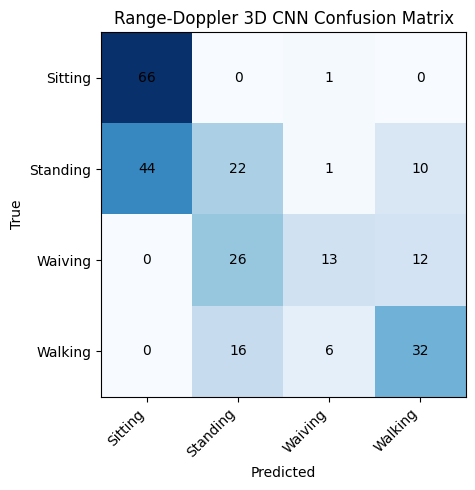


Final summary row


,Input Data Kinds,Network Structure,Accuracy,Loss
0,Only Range-Doppler,3D CNN,53.41,4.683


In [16]:
# Cell 7: Evaluate and print final result row
val_loss, val_acc = rd_model.evaluate(X_val, y_val_ohe, verbose=0)
print("Validation loss:", round(float(val_loss), 4))
print("Validation accuracy:", round(float(val_acc), 4))

probs = rd_model.predict(X_val, verbose=0)
pred = np.argmax(probs, axis=1)

print("\nClassification report")
print(classification_report(y_val_enc, pred, target_names=label_encoder_rd.classes_, zero_division=0))

cm = confusion_matrix(y_val_enc, pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Range-Doppler 3D CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes_rd), label_encoder_rd.classes_, rotation=45, ha="right")
plt.yticks(range(num_classes_rd), label_encoder_rd.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

result_row = pd.DataFrame([
    {
        "Input Data Kinds": "Only Range-Doppler",
        "Network Structure": "3D CNN",
        "Accuracy": round(float(val_acc) * 100, 2),
        "Loss": round(float(val_loss), 3),
    }
])

print("\nFinal summary row")
display(result_row)

In [17]:
# Cell 8: Save trained model and related artifacts
from datetime import datetime
import json

if "rd_model" not in globals():
    raise RuntimeError("rd_model is not available. Run model build/training cells first.")

base_dir = research_root if "research_root" in globals() else Path.cwd()
save_dir = base_dir / "trained_models"
save_dir.mkdir(parents=True, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
model_stem = f"range_doppler_3dcnn_{run_tag}"
model_path = save_dir / f"{model_stem}.keras"

# Save full Keras model (architecture + weights + optimizer state).
rd_model.save(model_path)

history_path = save_dir / f"{model_stem}_history.csv"
if "history_rd" in globals() and hasattr(history_rd, "history"):
    pd.DataFrame(history_rd.history).to_csv(history_path, index=False)
else:
    history_path = None

labels_path = save_dir / f"{model_stem}_labels.json"
labels = list(label_encoder_rd.classes_) if "label_encoder_rd" in globals() else []
with labels_path.open("w", encoding="utf-8") as f:
    json.dump({"classes": labels}, f, indent=2)

meta_path = save_dir / f"{model_stem}_meta.json"
trained_steps = int(rd_model.optimizer.iterations.numpy()) if hasattr(rd_model, "optimizer") else 0
meta = {
    "model_name": rd_model.name,
    "model_file": str(model_path),
    "dataset": TARGET_DATASET if "TARGET_DATASET" in globals() else None,
    "seq_len": int(SEQ_LEN) if "SEQ_LEN" in globals() else None,
    "stride": int(STRIDE_USED) if "STRIDE_USED" in globals() else None,
    "rd_grid": list(RD_GRID) if "RD_GRID" in globals() else None,
    "epochs": int(EPOCHS) if "EPOCHS" in globals() else None,
    "batch_size": int(BATCH_SIZE) if "BATCH_SIZE" in globals() else None,
    "val_loss": float(val_loss) if "val_loss" in globals() else None,
    "val_accuracy": float(val_acc) if "val_acc" in globals() else None,
    "trained_optimizer_steps": trained_steps,
}
with meta_path.open("w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Model saved:", model_path)
print("Labels saved:", labels_path)
print("Metadata saved:", meta_path)
if history_path is not None:
    print("History saved:", history_path)

if trained_steps == 0:
    print("Warning: model appears untrained (optimizer steps = 0).")

Model saved: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Work\Research Data\trained_models\range_doppler_3dcnn_20260416_023438.keras
Labels saved: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Work\Research Data\trained_models\range_doppler_3dcnn_20260416_023438_labels.json
Metadata saved: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Work\Research Data\trained_models\range_doppler_3dcnn_20260416_023438_meta.json
History saved: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Work\Research Data\trained_models\range_doppler_3dcnn_20260416_023438_history.csv
